In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 234s 297ms/step - accuracy: 0.7154 - loss: 0.5366 - val_accuracy: 0.7749 - val_loss: 0.4944
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 229s 293ms/step - accuracy: 0.7623 - loss: 0.4872 - val_accuracy: 0.8570 - val_loss: 0.3288
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 236s 302ms/step - accuracy: 0.9140 - loss: 0.2200 - val_accuracy: 0.8700 - val_loss: 0.3236
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 228s 292ms/step - accuracy: 0.9502 - loss: 0.1375 - val_accuracy: 0.8694 - val_loss: 0.3382
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 231s 295ms/step - accuracy: 0.9442 - loss: 0.1391 - val_accuracy: 0.8207 - val_loss: 0.4361


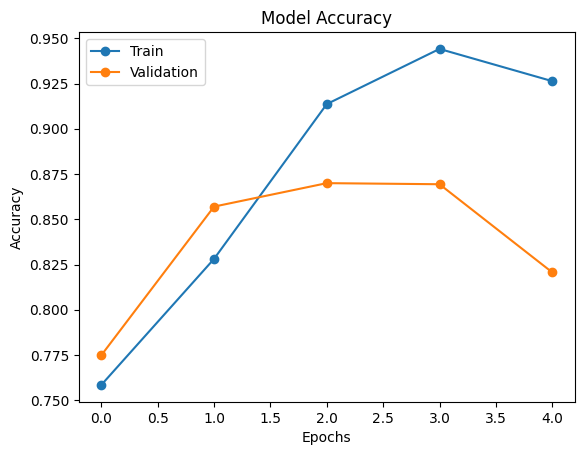

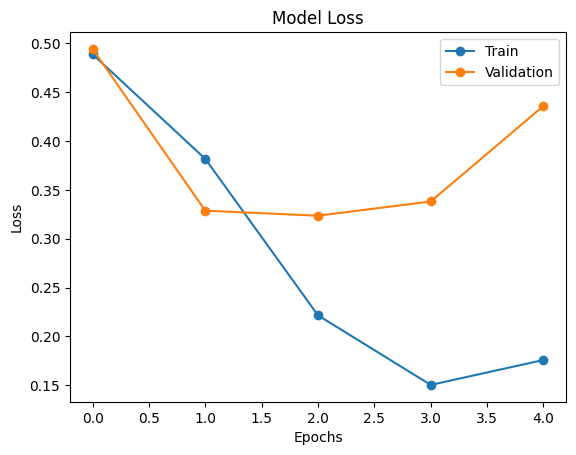

In [12]:
vocab_size = 10000
max_len = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32,
)


plt.figure()
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


plt.figure()
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()